# Workshop Agent 4 — The Data Analysis Agent

**Book:** *Agents* by Imran Ahmad (Packt Publishing, 2026)  
**Chapter Ref:** Chapter 8 — Data Analysis and Reasoning Agents, §8.1–§8.1.2 (pp. 204–211)

In this hands-on notebook you will build a **Data Analysis Agent** — an agent
that turns a plain-English question into code, runs it over a dataset, and
recommends the right visualization. You will see a natural-language question
become a live chart recommendation plus a statistical readout in seconds: a
rule-based recommender maps analytical intent to chart types, while a
statistical reasoning layer computes descriptive statistics, fits an OLS
regression, flags anomalies with z-scores, and narrates the findings in plain
language. The full pipeline runs offline in **Simulation Mode** — no API key
is required — and every agent action is traced with color-coded logging
(Blue/Green/Red).


In [ ]:
# Google Colab bootstrap — runs only on Colab, no-op everywhere else.
# Locally you are already inside the agent folder with requirements installed.
import os
import sys

if "google.colab" in sys.modules:
    AGENT_DIR = "04-data-analysis-agent"
    if not os.path.exists("/content/repo"):
        os.system("git clone --depth 1 https://github.com/cloudanum/ws-10-agents /content/repo")
    os.chdir(f"/content/repo/{AGENT_DIR}")
    # On Colab, prefer requirements-colab.txt when present: it drops pins that
    # cannot coexist with Colab's preinstalled stack (e.g. langchain 0.2.16
    # requires numpy<2 on Python 3.13, while Colab ships numpy 2.x).
    req_file = "requirements-colab.txt" if os.path.exists("requirements-colab.txt") else "requirements.txt"
    # Keep Colab's preinstalled scientific/kernel stack: the kernel already has
    # numpy, pandas, pydantic and ipykernel loaded, so letting pip replace them
    # (e.g. building numpy 1.26.4 from source or upgrading ipykernel) breaks the
    # running kernel with ABI errors or an OOM kill. Filter those lines out of
    # requirements and constrain the rest of the install to the installed versions.
    import re
    from importlib.metadata import PackageNotFoundError, version
    filtered = [
        line for line in open(req_file)
        if not re.match(r"\s*(numpy|pandas|pydantic|jupyter|ipykernel)\b", line, re.IGNORECASE)
    ]
    with open("/tmp/colab_requirements.txt", "w") as fh:
        fh.writelines(filtered)
    pins = []
    for pkg in ("numpy", "pandas", "pydantic", "ipykernel"):
        try:
            pins.append(f"{pkg}=={version(pkg)}")
        except PackageNotFoundError:
            pass
    with open("/tmp/colab_constraints.txt", "w") as fh:
        fh.write("\n".join(pins) + "\n")
    import subprocess
    res = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "-r", "/tmp/colab_requirements.txt",
         "--constraint", "/tmp/colab_constraints.txt"],
        capture_output=True, text=True,
    )
    if res.returncode != 0:
        print("pip install failed — re-running without -q for the full resolver report:\n")
        subprocess.run(
            [sys.executable, "-m", "pip", "install",
             "-r", "/tmp/colab_requirements.txt",
             "--constraint", "/tmp/colab_constraints.txt"],
        )
        raise RuntimeError("Colab bootstrap: pip install failed (see resolver report above)")
    print(f"Colab setup complete ({req_file}) — working directory: {os.getcwd()}")
else:
    print("Not on Colab — skipping bootstrap (local setup already in place).")

---
## Section 0 — Environment Setup

This cell imports the shared utilities, resolves the API key through a
three-tier cascade (`.env` → `os.getenv` → `getpass`), and sets the global
`SIMULATION_MODE` flag. If no key is found, the notebook activates Simulation
Mode automatically.

In [1]:
# ── Section 0: Environment Setup ─────────────────────────────
# Ref: Strategy §4.1 — Three-tier API key resolution

import sys, os, json, re, textwrap
import warnings
warnings.filterwarnings('ignore')

# Add project root to path for utils imports
if '.' not in sys.path:
    sys.path.insert(0, '.')

from utils import load_api_key, log, MockLLM, llm_call, fail_gracefully

# ── Resolve API key ──────────────────────────────────────────
API_KEY, SIMULATION_MODE = load_api_key()

client = None
if not SIMULATION_MODE:
    try:
        from openai import OpenAI
        client = OpenAI(api_key=API_KEY)
        log.success('OpenAI client initialized. Running in LIVE mode.')
    except Exception as e:
        log.error(f'OpenAI client init failed: {e}')
        SIMULATION_MODE = True
        log.info('Falling back to SIMULATION MODE.')

if SIMULATION_MODE:
    log.info('No API key detected. Running in SIMULATION MODE.')
    log.info('All outputs are chapter-accurate mocks. See AGENTS.md.')

[INFO 18:23:35] No API key detected. Running in SIMULATION MODE.
[INFO 18:23:35] All outputs are chapter-accurate mocks. See AGENTS.md.


---
## Section 1 — The Data Analysis Agent

**Chapter Ref:** §8.1 (pp. 204–211)

Data analysis is one of the most important capabilities in modern intelligent
systems. By embedding reasoning capabilities into the analysis workflow, agents
move beyond static queries to interpret intent, select appropriate methods, and
explain results — turning data analysis from a manual, tool-driven process into
an intelligent, conversational one.

At the core of a Data Analysis agent lies a **cognitive loop** that integrates:

1. **Intent analysis and planning** — The LLM Reasoning Core interprets the
   user's natural language query, extracting analytical intent and temporal scope.
2. **Code formulation and execution** — The plan is translated into executable
   code (Python/SQL) and run against the dataset.
3. **Visualization and analysis** — Results are rendered in the most effective
   visual form, accompanied by statistical reasoning.
4. **Presentation and refinement** — Insights are delivered with a summary;
   the user can refine, creating a feedback loop.

### Figure 8.1 — The Cognitive Loop of a Data Analysis Agent


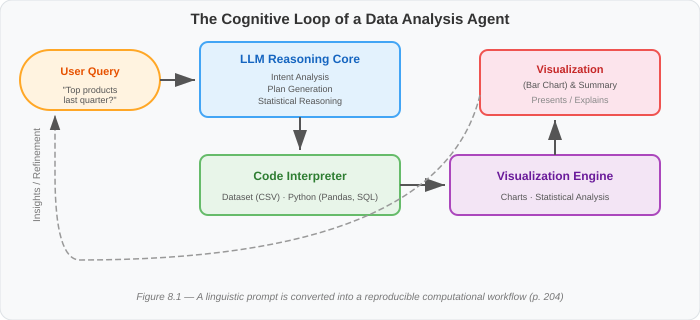

In [2]:
# ── Figure 8.1 — Cognitive Loop of a Data Analysis Agent (SVG) ──
# Ref: §8.1, p. 204

from IPython.display import SVG, display

fig_8_1 = """
<svg viewBox="0 0 700 320" xmlns="http://www.w3.org/2000/svg" font-family="Arial, sans-serif">
  <defs><marker id="a81" markerWidth="10" markerHeight="7" refX="10" refY="3.5" orient="auto"><polygon points="0 0,10 3.5,0 7" fill="#555"/></marker></defs>
  <rect width="700" height="320" rx="12" fill="#f8f9fa" stroke="#dee2e6"/>
  <text x="350" y="24" text-anchor="middle" font-size="15" font-weight="bold" fill="#333">The Cognitive Loop of a Data Analysis Agent</text>
  <!-- User Query -->
  <rect x="20" y="50" width="140" height="60" rx="30" fill="#fff3e0" stroke="#ffa726" stroke-width="2"/>
  <text x="90" y="75" text-anchor="middle" font-size="11" font-weight="bold" fill="#e65100">User Query</text>
  <text x="90" y="93" text-anchor="middle" font-size="9" fill="#555">"Top products</text>
  <text x="90" y="103" text-anchor="middle" font-size="9" fill="#555">last quarter?"</text>
  <!-- LLM Reasoning Core -->
  <rect x="200" y="42" width="200" height="75" rx="8" fill="#e3f2fd" stroke="#42a5f5" stroke-width="2"/>
  <text x="300" y="63" text-anchor="middle" font-size="12" font-weight="bold" fill="#1565c0">LLM Reasoning Core</text>
  <text x="300" y="80" text-anchor="middle" font-size="9" fill="#555">Intent Analysis</text>
  <text x="300" y="92" text-anchor="middle" font-size="9" fill="#555">Plan Generation</text>
  <text x="300" y="104" text-anchor="middle" font-size="9" fill="#555">Statistical Reasoning</text>
  <!-- Code Interpreter -->
  <rect x="200" y="155" width="200" height="60" rx="8" fill="#e8f5e9" stroke="#66bb6a" stroke-width="2"/>
  <text x="300" y="180" text-anchor="middle" font-size="12" font-weight="bold" fill="#2e7d32">Code Interpreter</text>
  <text x="300" y="200" text-anchor="middle" font-size="9" fill="#555">Dataset (CSV) · Python (Pandas, SQL)</text>
  <!-- Visualization Engine -->
  <rect x="450" y="155" width="210" height="60" rx="8" fill="#f3e5f5" stroke="#ab47bc" stroke-width="2"/>
  <text x="555" y="180" text-anchor="middle" font-size="12" font-weight="bold" fill="#6a1b9a">Visualization Engine</text>
  <text x="555" y="200" text-anchor="middle" font-size="9" fill="#555">Charts · Statistical Analysis</text>
  <!-- Output -->
  <rect x="480" y="50" width="180" height="65" rx="8" fill="#fce4ec" stroke="#ef5350" stroke-width="2"/>
  <text x="570" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#c62828">Visualization</text>
  <text x="570" y="88" text-anchor="middle" font-size="9" fill="#555">(Bar Chart) &amp; Summary</text>
  <text x="570" y="103" text-anchor="middle" font-size="9" fill="#888">Presents / Explains</text>
  <!-- Feedback arrow -->
  <text x="40" y="175" text-anchor="middle" font-size="10" fill="#777" transform="rotate(-90, 40, 175)">Insights / Refinement</text>
  <!-- Arrows -->
  <line x1="160" y1="80" x2="195" y2="80" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="300" y1="117" x2="300" y2="150" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="400" y1="185" x2="445" y2="185" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <line x1="555" y1="155" x2="555" y2="120" stroke="#555" stroke-width="2" marker-end="url(#a81)"/>
  <!-- Feedback loop -->
  <path d="M 480 95 Q 440 260 80 260 Q 55 260 55 175 L 55 115" fill="none" stroke="#999" stroke-width="1.5" stroke-dasharray="6,3" marker-end="url(#a81)"/>
  <!-- Legend -->
  <text x="350" y="300" text-anchor="middle" font-size="10" fill="#777" font-style="italic">Figure 8.1 — A linguistic prompt is converted into a reproducible computational workflow (p. 204)</text>
</svg>
"""
display(SVG(fig_8_1))


### Section 1.1 — Visualization Recommendation Systems

**Chapter Ref:** §8.1.1 (pp. 206–209)

A visualization recommendation system operates as a decision-making pipeline:

1. **Query analysis** — Parse the prompt to extract intent (trend, compare,
   relationship).
2. **Schema recognition** — Examine variable types (temporal, categorical,
   numeric).
3. **Decision branching** — Map intent + schema to chart type:
   - Time-series → Line Chart
   - Categorical Comparison → Bar Chart
   - Correlation / Relationship → Scatter Plot or Table
4. **Output and refinement** — Render with a summary; the user can refine
   through follow-up queries.

> **📝 Note — Production Considerations (p. 207)**  
> The rule-based `recommend_visualization()` below is intentionally simplified for pedagogy. In production, ambiguous queries like "show me the data" may match multiple keyword categories or none at all, requiring a confidence-scoring layer or an LLM-based intent classifier. As the chart palette grows beyond line/bar/scatter/table to heatmaps, box plots, and geographic maps, a flat keyword list becomes difficult to maintain — production systems typically replace it with a learned model or decision tree trained on query–visualization pairs.

> **📝 Note — Self-Optimizing Visualization (p. 209)**  
> Over time, reinforcement mechanisms enable the system to learn from user behavior. If users frequently replace a bar chart with a line chart for trend-related queries, the model adapts its decision weights, transforming visualization recommendation into a self-optimizing subsystem that mirrors human analytical intuition.


In [3]:
# ── Section 1.1: Visualization Recommender ───────────────────
# Ref: §8.1.1 — recommend_visualization() from chapter
# Fallback: "table" per Strategy §4.3.4

import pandas as pd

@fail_gracefully(fallback_value='table', section='8.1.1')
def recommend_visualization(df: pd.DataFrame, query: str) -> str:
    """Recommend a visualization type based on the user's query.

    This is a pedagogical, rule-based implementation. Production systems
    should use an LLM-based intent classifier rather than keyword rules.

    Parameters
    ----------
    df : pd.DataFrame
        The dataset under analysis (used for schema recognition).
    query : str
        Natural language query from the user.

    Returns
    -------
    str
        One of: "line", "bar", "scatter", "table".

    Ref: §8.1.1, recommend_visualization() — Chapter 8
    """
    # NOTE: This is a pedagogical implementation. Production systems should
    # use an LLM-based intent classifier rather than keyword rules.
    q = query.lower()

    if any(k in q for k in ["trend", "over time", "timeline"]):
        return "line"
    if any(k in q for k in ["compare", "by ", "across", "versus"]):
        return "bar"
    if any(k in q for k in ["relationship", "correlation", "scatter"]):
        return "scatter"
    return "table"


# ── Demo: 4 sample queries ──────────────────────────────────
df_demo = pd.read_csv('data/sample_sales_data.csv')

sample_queries = [
    "Show me the sales trend over time",
    "Compare revenue across regions",
    "Is there a relationship between marketing spend and revenue?",
    "Show me the raw data",
]

log.info('Visualization Recommender Demo', section='8.1.1')
for query in sample_queries:
    viz_type = recommend_visualization(df_demo, query)
    log.success(f'Query: "{query}" → Recommended: {viz_type}', section='8.1.1')

[INFO 18:23:43 §8.1.1] Visualization Recommender Demo
[INFO 18:23:43 §8.1.1] Entering recommend_visualization()
[SUCCESS 18:23:43 §8.1.1] recommend_visualization() completed.
[SUCCESS 18:23:43 §8.1.1] Query: "Show me the sales trend over time" → Recommended: line
[INFO 18:23:43 §8.1.1] Entering recommend_visualization()
[SUCCESS 18:23:43 §8.1.1] recommend_visualization() completed.
[SUCCESS 18:23:43 §8.1.1] Query: "Compare revenue across regions" → Recommended: bar
[INFO 18:23:43 §8.1.1] Entering recommend_visualization()
[SUCCESS 18:23:43 §8.1.1] recommend_visualization() completed.
[SUCCESS 18:23:43 §8.1.1] Query: "Is there a relationship between marketing spend and revenue?" → Recommended: scatter
[INFO 18:23:43 §8.1.1] Entering recommend_visualization()
[SUCCESS 18:23:43 §8.1.1] recommend_visualization() completed.
[SUCCESS 18:23:43 §8.1.1] Query: "Show me the raw data" → Recommended: table


### Section 1.2 — Statistical Reasoning Capabilities

**Chapter Ref:** §8.1.2 (pp. 209–211)

Visualization provides perception, but statistical reasoning provides understanding.
The agent performs three complementary functions:

1. **Descriptive statistics** — `df.describe()`, standard deviation, correlation
   coefficients. These form the quantitative foundation for reasoning.
2. **Inferential and diagnostic analysis** — OLS regression to quantify
   relationships (e.g., "Did marketing spend influence revenue growth?").
3. **Anomaly detection** — Z-score-based outlier identification to flag
   data integrity issues and surface unexpected patterns.

> **📝 Note — Hybrid Reasoning Layer (p. 210)**  
> In practice, the statistical reasoning module operates as a hybrid of symbolic and numerical computation. Symbolic reasoning (often powered by the LLM core) interprets user intent and formulates hypotheses. Numerical computation (via Pandas, NumPy, Statsmodels) performs precise calculations. The outputs are synthesized into a coherent narrative that balances technical accuracy with communicative clarity.


In [4]:
# ── Section 1.2: Descriptive Statistics ─────────────────────
# Ref: §8.1.2 — df.describe(), variability, correlation

import numpy as np

df = pd.read_csv('data/sample_sales_data.csv')

log.info('Loading sample_sales_data.csv (100 rows, seed=42)', section='8.1.2')

@fail_gracefully(fallback_value=None, section='8.1.2')
def compute_descriptive_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute summary statistics for the sales dataset.

    Ref: §8.1.2 — Descriptive statistics and summarization
    """
    summary = df.describe(include='all')
    variability = df['sales'].std()
    correlation = df[['sales', 'marketing_spend', 'revenue']].corr(method='pearson')

    log.info(f'Sales variability (std): {variability:.2f}', section='8.1.2')
    log.info(f'Pearson correlation (marketing_spend ↔ revenue): '
             f'{correlation.loc["marketing_spend", "revenue"]:.3f}', section='8.1.2')
    return summary

summary = compute_descriptive_stats(df)
if summary is not None:
    display(summary)

[INFO 18:23:43 §8.1.2] Loading sample_sales_data.csv (100 rows, seed=42)
[INFO 18:23:43 §8.1.2] Entering compute_descriptive_stats()
[INFO 18:23:43 §8.1.2] Sales variability (std): 56.24
[INFO 18:23:43 §8.1.2] Pearson correlation (marketing_spend ↔ revenue): 0.880
[SUCCESS 18:23:43 §8.1.2] compute_descriptive_stats() completed.


,date,region,product,sales,marketing_spend,revenue
count,100,100,100,100.000000,100.000000,100.000000
unique,100,4,3,NaN,NaN,NaN
top,2025-01-01,West,Widget C,NaN,NaN,NaN
freq,1,30,39,NaN,NaN,NaN
mean,NaN,NaN,NaN,111.250000,2812.083200,6916.211600
std,NaN,NaN,NaN,56.238018,1282.613731,3636.143943
min,NaN,NaN,NaN,10.000000,502.340000,754.350000
25%,NaN,NaN,NaN,61.750000,1709.397500,4044.850000
50%,NaN,NaN,NaN,125.000000,2683.495000,6139.215000
75%,NaN,NaN,NaN,161.250000,3864.860000,9140.427500


In [5]:
# ── Section 1.2: OLS Regression ─────────────────────────────
# Ref: §8.1.2 — sm.OLS() regression, chapter verbatim

import statsmodels.api as sm

@fail_gracefully(fallback_value=None, section='8.1.2')
def run_ols_regression(df: pd.DataFrame):
    """Run OLS regression: revenue ~ marketing_spend.

    Ref: §8.1.2 — Inferential and diagnostic analysis
    """
    X = sm.add_constant(df['marketing_spend'])
    model = sm.OLS(df['revenue'], X).fit()

    r_squared = model.rsquared
    p_value = model.pvalues.iloc[1]  # p-value for marketing_spend
    coeff = model.params.iloc[1]

    log.success(
        f'OLS Results: R²={r_squared:.3f}, '
        f'marketing_spend coeff={coeff:.4f}, p={p_value:.2e}',
        section='8.1.2'
    )
    return model

model = run_ols_regression(df)
if model is not None:
    print(model.summary())

[INFO 18:24:01 §8.1.2] Entering run_ols_regression()
[SUCCESS 18:24:01 §8.1.2] OLS Results: R²=0.774, marketing_spend coeff=2.4947, p=1.88e-33
[SUCCESS 18:24:01 §8.1.2] run_ols_regression() completed.
                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.774
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     336.4
Date:                Sat, 29 Aug 2026   Prob (F-statistic):           1.88e-33
Time:                        18:24:01   Log-Likelihood:                -886.81
No. Observations:                 100   AIC:                             1778.
Df Residuals:                      98   BIC:                             1783.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
         

In [6]:
# ── Section 1.2: Anomaly Detection ──────────────────────────
# Ref: §8.1.2 — Z-score outlier detection, chapter verbatim

@fail_gracefully(fallback_value=pd.DataFrame(), section='8.1.2')
def detect_anomalies(df: pd.DataFrame, column: str = 'sales',
                     threshold: float = 3.0) -> pd.DataFrame:
    """Detect anomalies using z-score method.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset.
    column : str
        Column to analyze for outliers.
    threshold : float
        Z-score threshold (default 3.0).

    Returns
    -------
    pd.DataFrame
        Rows where |z-score| > threshold.

    Ref: §8.1.2 — Anomaly detection and uncertainty quantification
    """
    df = df.copy()
    df['zscore'] = (df[column] - df[column].mean()) / df[column].std()
    anomalies = df[df['zscore'].abs() > threshold]

    if len(anomalies) > 0:
        for _, row in anomalies.iterrows():
            log.success(
                f'Anomaly detected: date={row["date"]}, region={row["region"]}, '
                f'{column}={row[column]}, z-score={row["zscore"]:.2f}',
                section='8.1.2'
            )
    else:
        log.info(f'No anomalies found (threshold z>{threshold})', section='8.1.2')

    return anomalies

anomalies = detect_anomalies(df)
if not anomalies.empty:
    display(anomalies[['date', 'region', 'product', 'sales', 'zscore']])

[INFO 18:24:01 §8.1.2] Entering detect_anomalies()
[INFO 18:24:01 §8.1.2] No anomalies found (threshold z>3.0)
[SUCCESS 18:24:01 §8.1.2] detect_anomalies() completed.


In [7]:
# ── Section 1.2: Natural Language Interpretation ─────────────
# Ref: §8.1.2 — LLM-powered interpretation via llm_call()
# Mock key: "stats_interpretation"

@fail_gracefully(fallback_value='Interpretation unavailable.', section='8.1.2')
def interpret_statistics(df: pd.DataFrame) -> str:
    """Generate a natural language interpretation of the statistical results.

    Uses llm_call() with context_key='stats_interpretation'.

    Ref: §8.1.2 — Statistical reasoning with LLM interpretation
    """
    system = (
        'You are a data analyst. Interpret the following statistical results '
        'in plain language for a business audience.'
    )
    corr_val = df['marketing_spend'].corr(df['revenue'])
    std_val = df['sales'].std()
    z = (df['sales'] - df['sales'].mean()) / df['sales'].std()
    n_anomalies = int((z.abs() > 3).sum())
    user = (
        f'Dataset summary:\n'
        f'- marketing_spend ↔ revenue correlation: {corr_val:.3f}\n'
        f'- Sales std: {std_val:.2f}\n'
        f'- Anomalies (z>3): {n_anomalies}\n'
        f'Provide a concise business interpretation.'
    )
    return llm_call(
        system, user,
        context_key='stats_interpretation',
        simulation_mode=SIMULATION_MODE,
        client=client,
    )

interpretation = interpret_statistics(df)
log.success('Statistical interpretation:', section='8.1.2')
print(f'\n{interpretation}')

[INFO 18:24:01 §8.1.2] Entering interpret_statistics()
[INFO 18:24:01 §8.1.2] MockLLM serving 'stats_interpretation' (Section 8.1.2)
[SUCCESS 18:24:01 §8.1.2] interpret_statistics() completed.
[SUCCESS 18:24:01 §8.1.2] Statistical interpretation:

Marketing spend explains approximately 62% of the variation in revenue, indicating a strong positive correlation. Sales in Q2 for Region East appear unusually high, possibly due to promotional pricing or data entry anomalies.


---
## Summary

- A Data Analysis Agent closes the gap between natural-language questions and
  reproducible computation through a four-stage **cognitive loop** (§8.1).
- Rule-based intent matching recommends appropriate visualizations — line,
  bar, scatter, or table — directly from query keywords (§8.1.1).
- Statistical reasoning — descriptive statistics, OLS regression, and z-score
  anomaly detection — turns perception into understanding (§8.1.2).
- `llm_call()` routes interpretation through the live API when a key is
  present and through `MockLLM` otherwise, so the notebook runs identically
  in both modes.

**Next:** Chapter 8 continues with the Verification & Validation Agent (§8.2)
and the General Problem Solver (§8.3) — see the book, pp. 211–219.
